In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Carga de datos

In [2]:
path = 'https://raw.githubusercontent.com/Jero2110/Big_Data_Phase05/refs/heads/main/data/Anexo%201%20-%20Dataset4.csv'

df = pd.read_csv(path, sep=",")

print('Datos cargados correctamente')
df.head()

Datos cargados correctamente


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


# Exploración inicial

In [3]:
def explorar_dataset(df):
    """Muestra de la estructura básica del dataset."""
    print("--- INFORMACIÓN GENERAL ---")
    print(df.info())
    print("\n--- VALORES NULOS POR COLUMNA ---")
    print(df.isnull().sum())

In [4]:
def analizar_columnas(df, columnas, graficos=None):
    """
    Analiza columnas específicas de un DataFrame.
    
    Parámetros:
    - df: El DataFrame.
    - columnas: Lista de nombres de columnas a analizar (ej. ['edad', 'ciudad']).
    - graficos: Puede ser None (sin gráficos), 'individual' o 'juntos'.
    """
    # 1. Análisis Estadístico en Consola
    for col in columnas:
        if col not in df.columns:
            print(col, "no existe en el dataset.")
            continue
            
        print(f"\n================ ANÁLISIS DE: {col} ================")
        if pd.api.types.is_numeric_dtype(df[col]):
            print(f"Tipo: Numérico")
            print(f"Media: {df[col].mean():.2f} | Mediana: {df[col].median():.2f}")
            print(f"Mín: {df[col].min()} | Máx: {df[col].max()} | Desv. Estándar: {df[col].std():.2f}")
        else:
            print(f"Tipo: Categórico / Texto")
            print(f"Valores únicos: {df[col].nunique()}")
            print("Top 5 valores más frecuentes:")
            print(df[col].value_counts().head(5))

    # 2. Generación de Gráficos
    if graficos is None:
        return # Finaliza sin graficar
        
    num_cols = len(columnas)
    
    if graficos == 'juntos':
        # Crea una cuadrícula automática (subplots)
        fig, axes = plt.subplots(nrows=int(np.ceil(num_cols/2)), ncols=2, figsize=(14, num_cols * 3.5))
        axes = axes.flatten() # Aplana la matriz para iterar fácil
        
        for i, col in enumerate(columnas):
            _generar_grafico(df, col, axes[i])
            axes[i].set_title(f"Distribución de {col}")
            
        # Oculta los subplots vacíos si el número de columnas es impar
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])
            
        plt.tight_layout()
        plt.show()
        
    elif graficos == 'individual':
        for col in columnas:
            fig, ax = plt.subplots(figsize=(7, 4))
            _generar_grafico(df, col, ax)
            ax.set_title(f"Distribución de {col}")
            plt.tight_layout()
            plt.show()

def _generar_grafico(df, col, ax):
    """Función interna de apoyo para decidir el tipo de gráfico gráfico."""
    if pd.api.types.is_numeric_dtype(df[col]):
        # Si es numérico, dibuja un histograma con línea de densidad
        sns.histplot(df[col].dropna(), kde=True, ax=ax, color='skyblue')
    else:
        # Si es categórico, dibuja un gráfico de barras
        top_categorias = df[col].value_counts()
        sns.barplot(x=top_categorias.values, y=top_categorias.index, ax=ax, palette='viridis', hue=top_categorias.index, legend=False)


--- INFORMACIÓN GENERAL ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
None

--- VALORES NULOS POR COLUMNA ---
age               0
workc

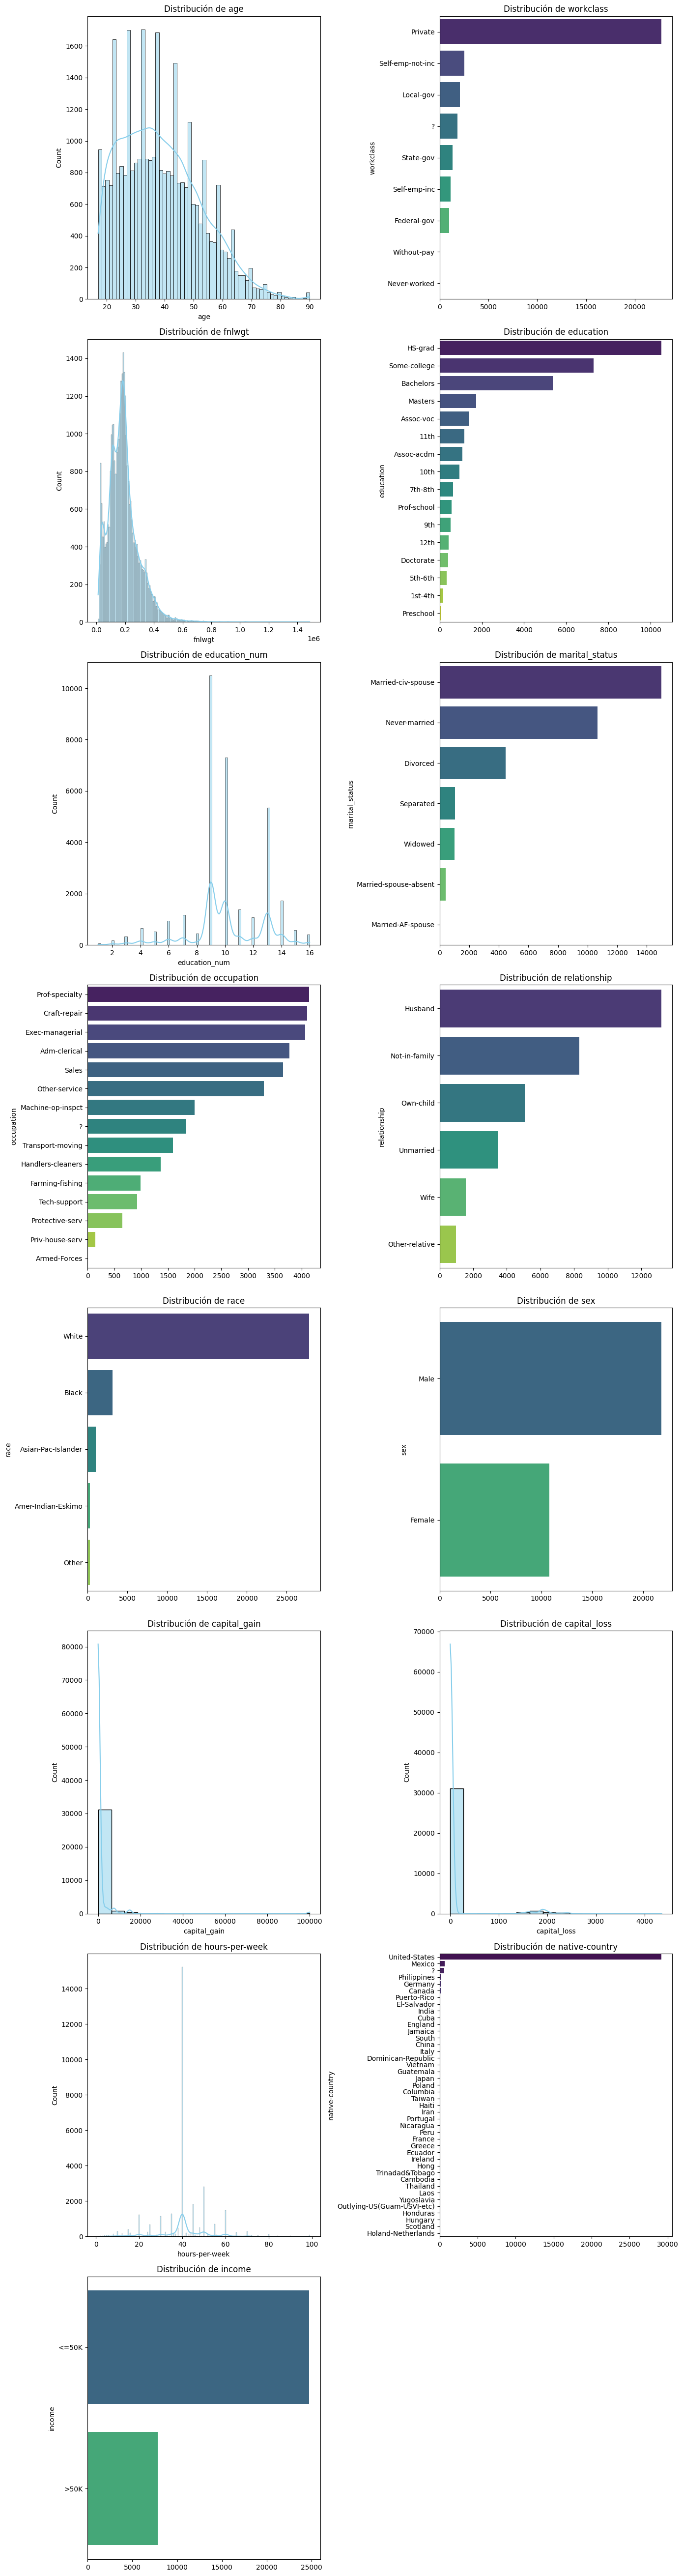

In [5]:
# Investigamos qué tiene el archivo de forma rápida
explorar_dataset(df)

# Tomamos todas las columnas del conjunto de datos
cols = df.columns

# Analizamos el contenido de las columnas combinando todas las gráficas en un solo lienzo
analizar_columnas(df, columnas=cols, graficos='juntos')


## Limpieza

### Identificación de valores vacíos

In [6]:
# Reemplazamos los valores incoherentes (?) por nulos
df.replace('?', np.nan, inplace=True)

# Reemplaza el número 99999 en cualquier columna donde aparezca
df.replace({'capital_gain':99999}, np.nan, inplace=True)

explorar_dataset(df)

--- INFORMACIÓN GENERAL ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             32561 non-null  int64  
 1   workclass       30725 non-null  object 
 2   fnlwgt          32561 non-null  int64  
 3   education       32561 non-null  object 
 4   education_num   32561 non-null  int64  
 5   marital_status  32561 non-null  object 
 6   occupation      30718 non-null  object 
 7   relationship    32561 non-null  object 
 8   race            32561 non-null  object 
 9   sex             32561 non-null  object 
 10  capital_gain    32402 non-null  float64
 11  capital_loss    32561 non-null  int64  
 12  hours-per-week  32561 non-null  int64  
 13  native-country  31978 non-null  object 
 14  income          32561 non-null  object 
dtypes: float64(1), int64(5), object(9)
memory usage: 3.7+ MB
None

--- VALORES NULOS POR COLUMNA 


================ ANÁLISIS DE: age ================
Tipo: Numérico
Media: 38.40 | Mediana: 37.00
Mín: 17 | Máx: 90 | Desv. Estándar: 13.13

================ ANÁLISIS DE: workclass ================
Tipo: Categórico / Texto
Valores únicos: 7
Top 5 valores más frecuentes:
workclass
Private             22208
Self-emp-not-inc     2470
Local-gov            2062
State-gov            1278
Self-emp-inc         1040
Name: count, dtype: int64

================ ANÁLISIS DE: fnlwgt ================
Tipo: Numérico
Media: 189776.50 | Mediana: 178440.00
Mín: 13769 | Máx: 1484705 | Desv. Estándar: 105666.56

================ ANÁLISIS DE: education ================
Tipo: Categórico / Texto
Valores únicos: 16
Top 5 valores más frecuentes:
education
HS-grad         9818
Some-college    6667
Bachelors       5007
Masters         1610
Assoc-voc       1306
Name: count, dtype: int64

================ ANÁLISIS DE: education_num ================
Tipo: Numérico
Media: 10.11 | Mediana: 10.00
Mín: 1 | Máx: 16 | Des

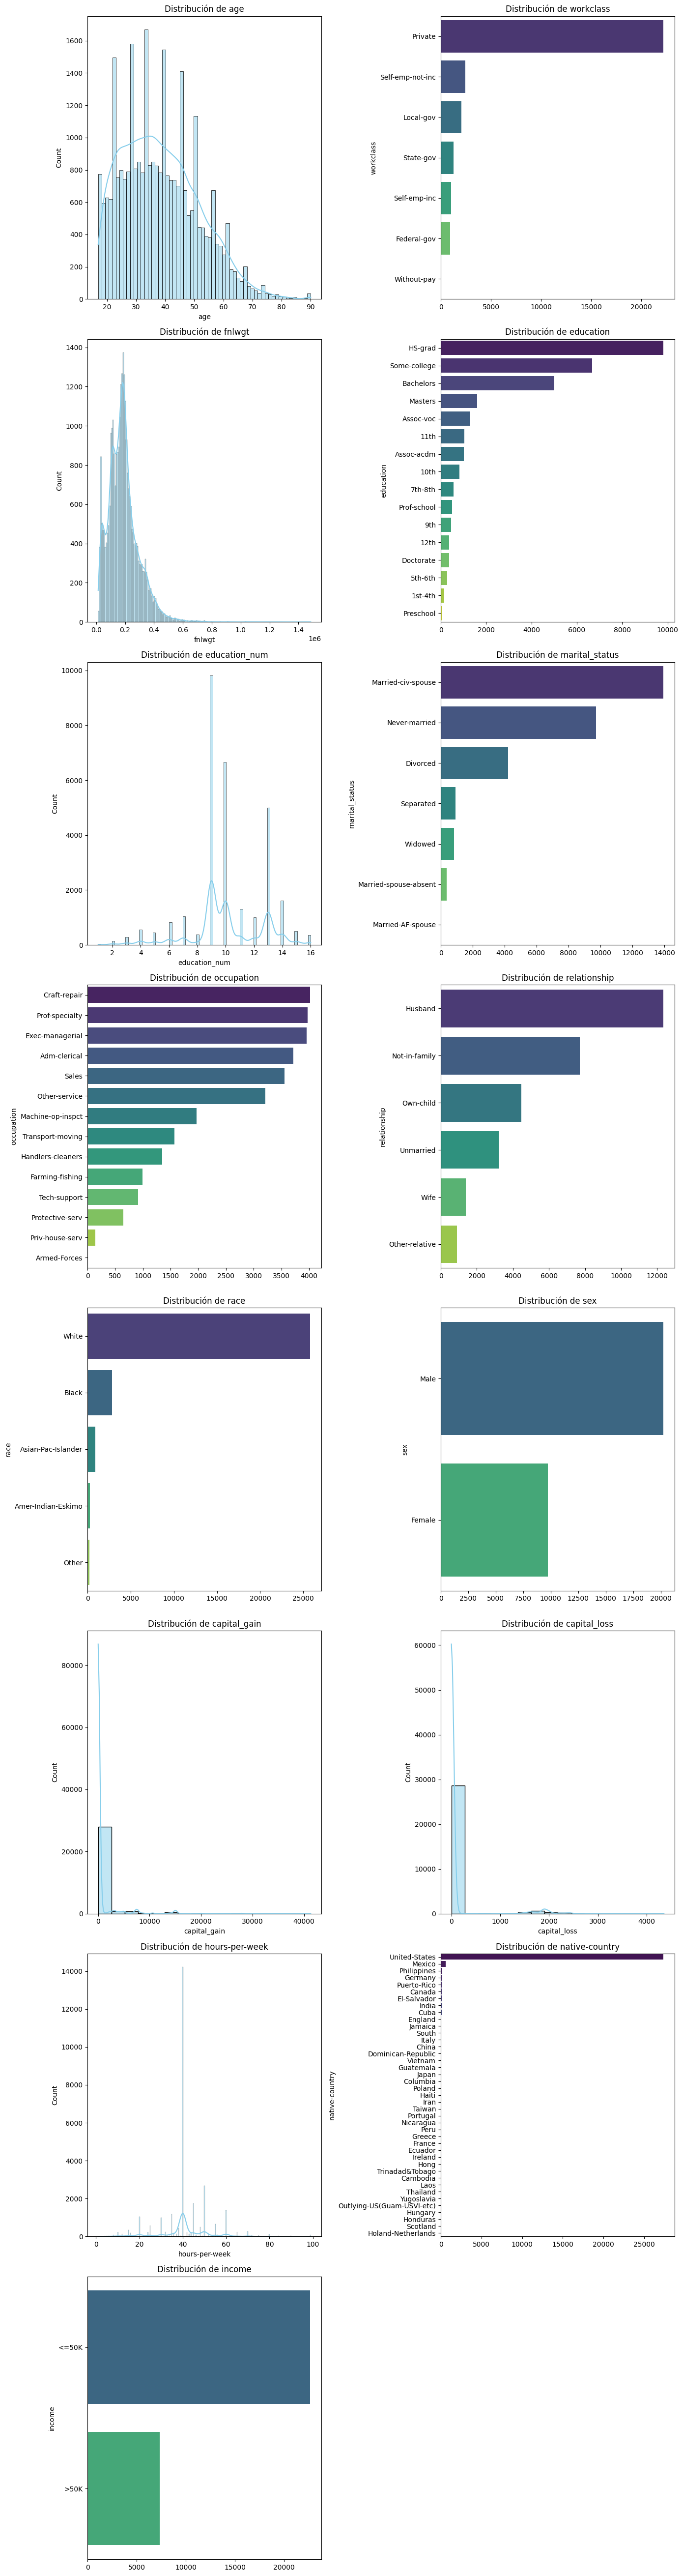

In [7]:
df.dropna(inplace=True)

analizar_columnas(df, columnas=cols, graficos='juntos')

### Limpieza de columnas que no se van a utilizar

In [8]:
df_limpio = df[df['native-country'].str.contains('United-States')]


In [9]:
cols_drop = ['fnlwgt', 'capital_gain', 'capital_loss', 'relationship', 'marital_status', 'native-country', 'education']

df_limpio.drop(cols_drop, axis=1, inplace=True)

cols = df_limpio.columns
cols_num     = ["age", "education_num", "hours-per-week"]
cols_onehot  = ["sex", "race", "occupation", "workclass"]  


/tmp/ipykernel_11107/4253587632.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio.drop(cols_drop, axis=1, inplace=True)


### Eliminación de valores atípicos

In [10]:
# =============================================================================
# 2. DETECCIÓN Y ELIMINACIÓN DE VALORES ATÍPICOS (OUTLIERS)
# =============================================================================
# Criterio: Se utiliza el método del Z-score estandarizado.
# Una observación se considera atípica si su Z-score en CUALQUIER variable
# numérica supera el umbral absoluto de 3.0 (equivalente a ~3 desviaciones
# estándar respecto a la media), lo que corresponde aproximadamente al 0.3%
# más extremo de una distribución normal.
#
# Justificación del umbral 3.0:
#   - Es el criterio más extendido en la literatura (Barnett & Lewis, 1994).
#   - Conserva la mayor parte de la variabilidad natural de los datos.
#   - Alternativa: IQR (rango intercuartílico) para distribuciones no normales.
#
# Procedimiento:
#   1. Se calcula el Z-score de cada columna numérica (excepto 'target').
#   2. Se marca como atípica toda fila cuyo Z-score máximo supere el umbral.
#   3. Las filas marcadas se eliminan del dataframe.

ZSCORE_THRESHOLD = 3.0
 
z_scores = np.abs(stats.zscore(df_limpio[cols_num], nan_policy="omit"))
mask_sin_outliers = (z_scores < ZSCORE_THRESHOLD).all(axis=1)
 
n_outliers = (~mask_sin_outliers).sum()
df_limpio  = df_limpio[mask_sin_outliers].reset_index(drop=True)
 
print(f"\nDETECCIÓN DE OUTLIERS (Z-score en cols numéricas, umbral={ZSCORE_THRESHOLD})")
print(f"  Outliers detectados : {n_outliers}  ({n_outliers/len(df_limpio)*100:.1f}%)")
print(f"  Instancias restantes: {len(df_limpio)}")


DETECCIÓN DE OUTLIERS (Z-score en cols numéricas, umbral=3.0)
  Outliers detectados : 588  (2.2%)
  Instancias restantes: 26777


## Exploración final

--- INFORMACIÓN GENERAL ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26777 entries, 0 to 26776
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             26777 non-null  int64 
 1   workclass       26777 non-null  object
 2   education_num   26777 non-null  int64 
 3   occupation      26777 non-null  object
 4   race            26777 non-null  object
 5   sex             26777 non-null  object
 6   hours-per-week  26777 non-null  int64 
 7   income          26777 non-null  object
dtypes: int64(3), object(5)
memory usage: 1.6+ MB
None

--- VALORES NULOS POR COLUMNA ---
age               0
workclass         0
education_num     0
occupation        0
race              0
sex               0
hours-per-week    0
income            0
dtype: int64

================ ANÁLISIS DE: age ================
Tipo: Numérico
Media: 38.20 | Mediana: 37.00
Mín: 17 | Máx: 78 | Desv. Estándar: 12.87

================ ANÁL

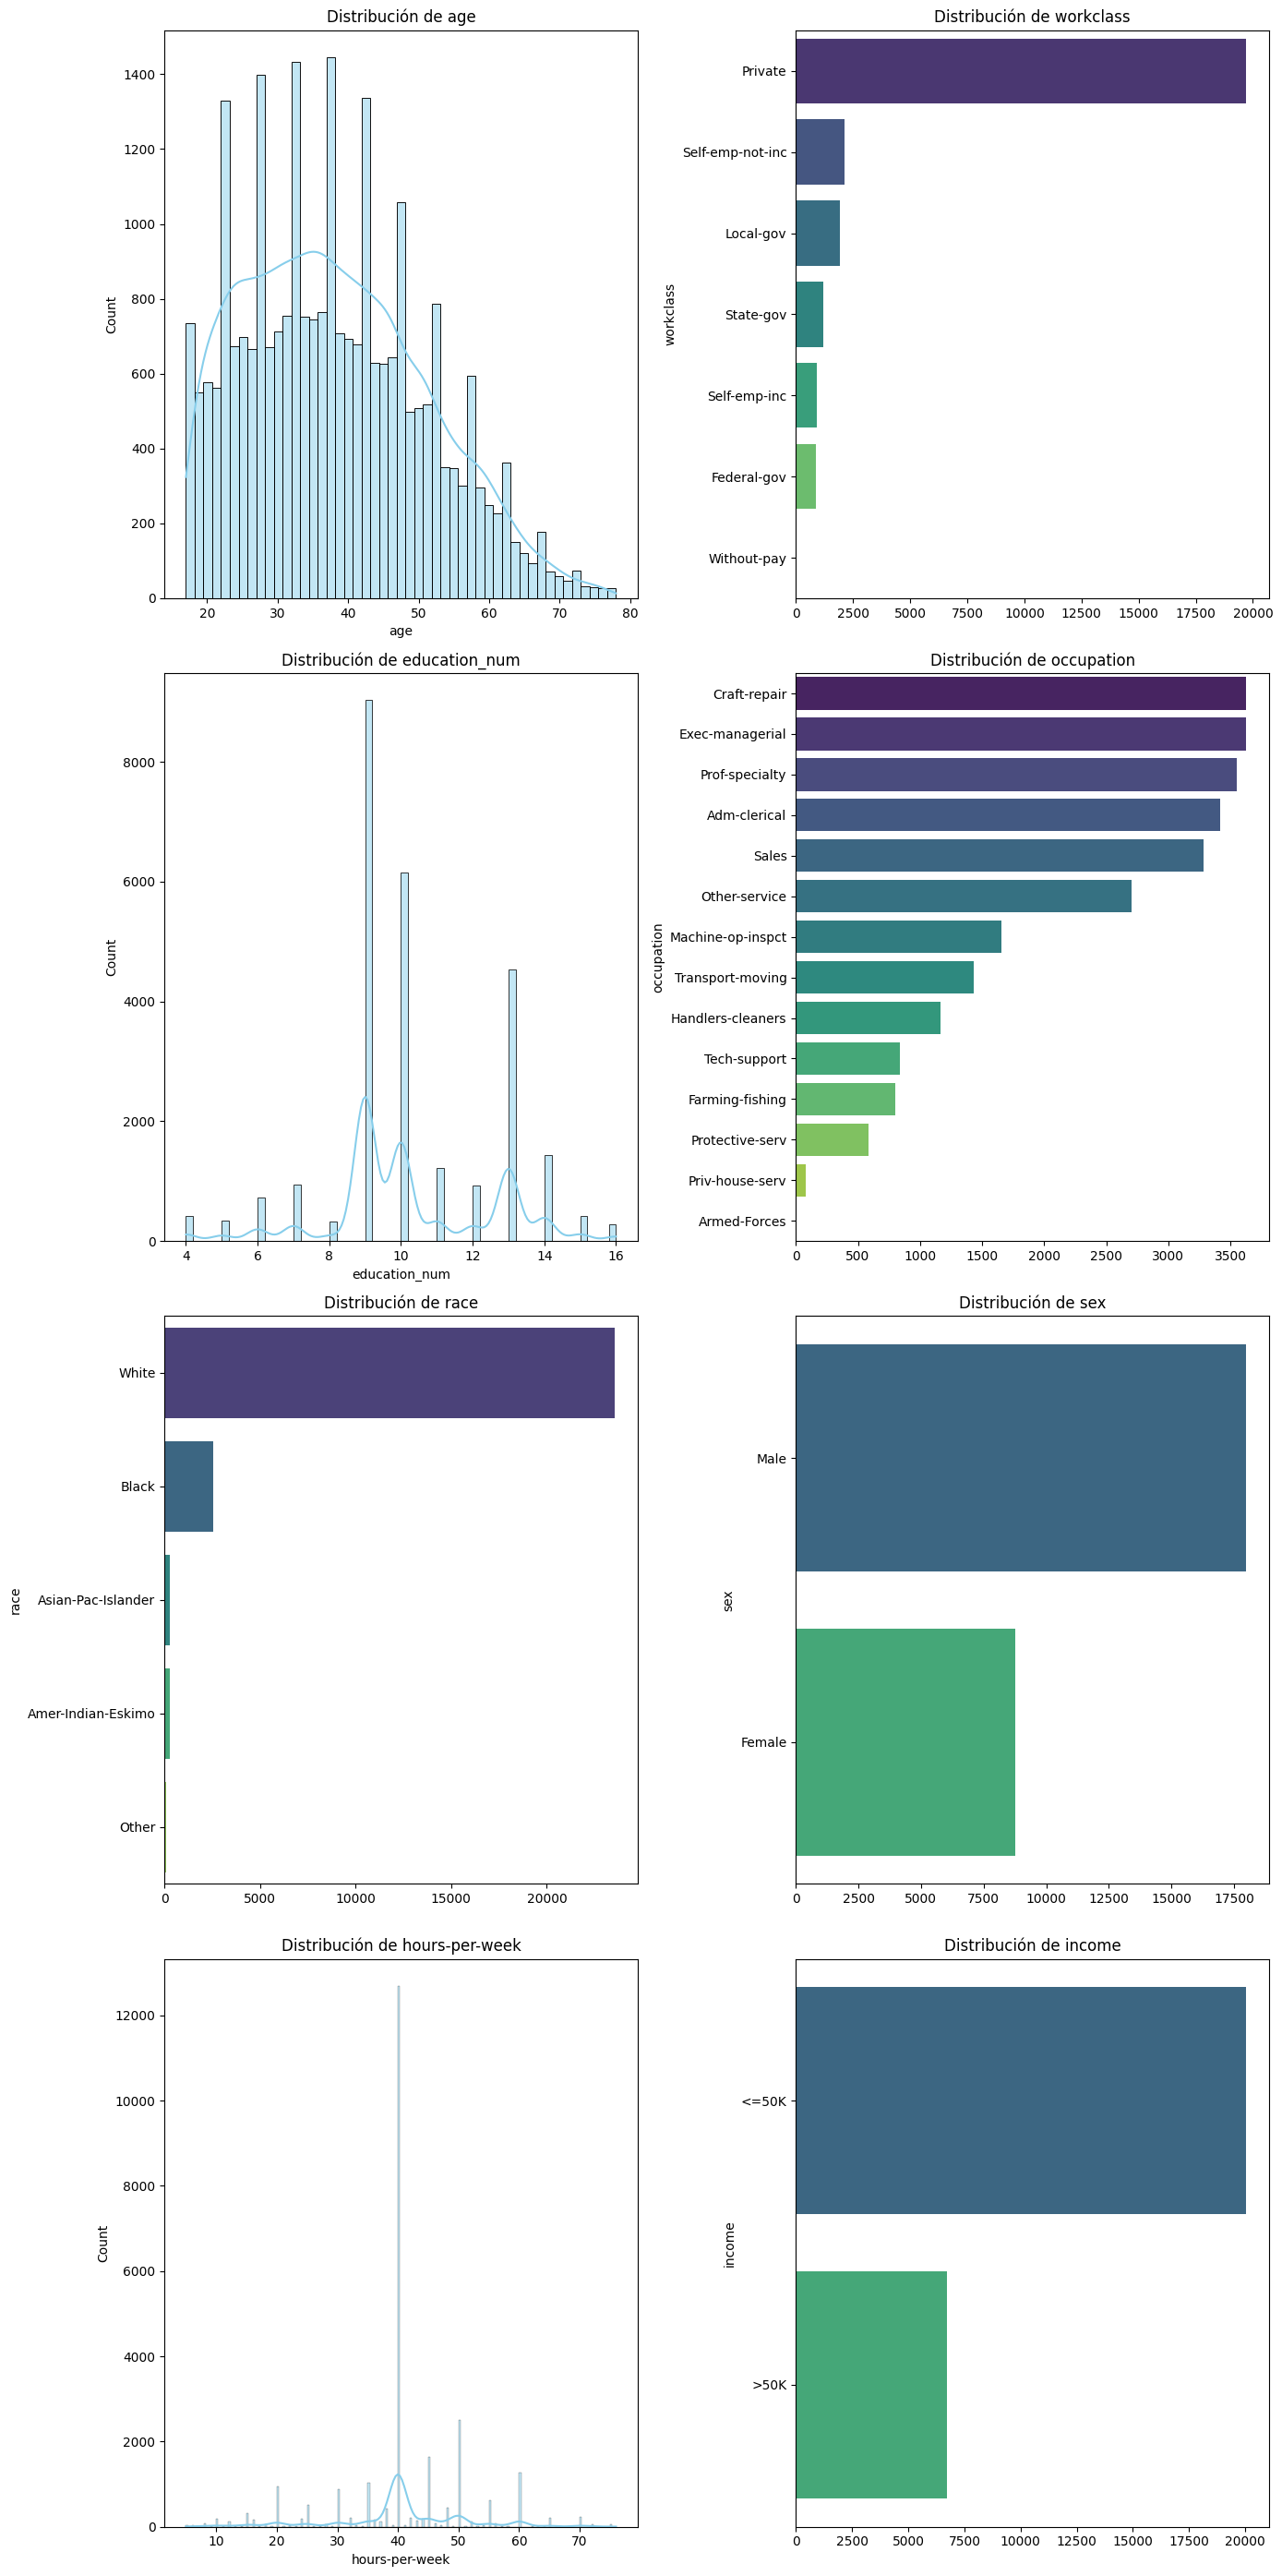

In [11]:
explorar_dataset(df_limpio)
analizar_columnas(df_limpio, columnas=cols, graficos='juntos')

# Análisis

In [12]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report,
    ConfusionMatrixDisplay
)

from sklearn.preprocessing import label_binarize

## Preparación de variables

In [13]:
df_limpio.columns

Index(['age', 'workclass', 'education_num', 'occupation', 'race', 'sex',
       'hours-per-week', 'income'],
      dtype='object')

In [ ]:
X = df_limpio.drop(columns=["income"])
y = df_limpio["income"]

## Normalización

In [15]:
# =============================================================================
# 4. NORMALIZACIÓN DE CARACTERÍSTICAS (MinMaxScaler)
# =============================================================================
# Método: Escalamiento Min-Max (normalización al rango [0, 1]).
#
# Fórmula: X_norm = (X - X_min) / (X_max - X_min)
#
# Justificación:
#   - KNN es sensible a la escala: variables con rangos grandes dominan
#     el cálculo de distancias euclidianas.
#   - Naive Bayes Gaussiano no requiere normalización estrictamente, pero
#     mantenerla homogeneiza el preprocesamiento del pipeline.
#   - Los Árboles de Decisión son invariantes a la escala; se normaliza
#     igualmente para mantener consistencia del experimento.
#
# IMPORTANTE: El escalador se ajusta ÚNICAMENTE sobre el conjunto de
# entrenamiento (fit_transform) y luego se aplica (transform) al conjunto
# de prueba. Esto evita la filtración de información (data leakage).

scaler = MinMaxScaler(feature_range=(0, 1))

## Partición del dataset

In [16]:
# =============================================================================
# 5. PARTICIÓN ENTRENAMIENTO / PRUEBA  (80% / 20%)
# =============================================================================
# Método: División aleatoria estratificada (stratify=y).
#
# La estratificación garantiza que la proporción de clases en el conjunto
# de entrenamiento y en el de prueba sea representativa de la distribución
# original, lo que es crítico en datasets con clases desbalanceadas.
#
# Parámetros:
#   test_size   = 0.20  → 20% para prueba,  80% para entrenamiento
#   random_state = 42   → semilla fija para reproducibilidad
#   stratify     = y    → mantiene proporción de clases en ambas particiones

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)



In [17]:
# =============================================================================
# 6. CONSTRUCCIÓN DEL PREPROCESADOR (ColumnTransformer)
# =============================================================================
# ColumnTransformer aplica transformaciones diferentes a distintos subconjuntos
# de columnas en un único paso vectorizado, garantizando que:
#   a) Las columnas numéricas se normalizan con MinMaxScaler.
#   b) Las columnas nominales se codifican con OneHotEncoder.
#   c) Las columnas ordinales (si las hay) se codifican con OrdinalEncoder.
#   d) El resto de columnas se descarta ('drop') o se pasa sin cambios ('passthrough').
#
# Parámetros clave de OneHotEncoder:
#   drop='first'         → elimina la primera categoría de cada variable para
#                          evitar la trampa de variables ficticias (multicolinealidad).
#                          Con k categorías genera k-1 columnas binarias.
#   handle_unknown='ignore' → si en el conjunto de prueba aparece una categoría
#                          no vista en entrenamiento, la fila recibe todos ceros
#                          en lugar de lanzar un error.
#   sparse_output=False  → devuelve un array denso; necesario para que sea
#                          compatible con todos los estimadores de sklearn.
 
# Transformador para columnas numéricas
transform_num = MinMaxScaler(feature_range=(0, 1))
 
# Transformador para columnas nominales
transform_cat = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

transformadores = [
        ("num",    transform_num, cols_num),
        ("onehot", transform_cat, cols_onehot),
    ]
 
preprocesador = ColumnTransformer(
    transformers=transformadores,
    remainder="drop"       # descarta cualquier columna no especificada
)

In [18]:
X_train_prep = preprocesador.fit_transform(X_train)
X_test_prep  = preprocesador.transform(X_test)

print(f"\nPREPROCESAMIENTO COMPLETADO")
print(f"  Columnas originales   : {X_train.shape[1]}")
print(f"  Columnas tras encoding: {X_train_prep.shape[1]}")
print(f"  X_train shape : {X_train_prep.shape}")
print(f"  X_test  shape : {X_test_prep.shape}")



PREPROCESAMIENTO COMPLETADO
  Columnas originales   : 7
  Columnas tras encoding: 27
  X_train shape : (21421, 27)
  X_test  shape : (5356, 27)


## Entrenamiento de modelos

In [19]:
# --- 6.1 K-Nearest Neighbors (KNN) -------------------------------------------
# Principio: clasifica una instancia según la clase mayoritaria entre sus
# k vecinos más cercanos en el espacio de características.
#
# Parámetros configurados:
#   n_neighbors = 5   → número de vecinos considerados; valor estándar de
#                       inicio (Cover & Hart, 1967). Puede optimizarse con
#                       GridSearchCV.
#   metric      = 'minkowski' con p=2 → equivale a distancia euclidiana,
#                       apropiada cuando las variables están normalizadas.
#   weights     = 'uniform' → todos los vecinos tienen igual peso.
#                       Alternativa: 'distance' (vecinos más cercanos pesan más).
#   algorithm   = 'auto' → sklearn selecciona la estructura de búsqueda
#                       (Ball Tree, KD-Tree o fuerza bruta) según los datos.

knn = KNeighborsClassifier(
    n_neighbors=5,
    metric="minkowski",
    p=2,
    weights="uniform",
    algorithm="auto"
)

In [20]:
# --- 6.2 Naive Bayes Gaussiano ------------------------------------------------
# Principio: aplica el teorema de Bayes asumiendo independencia condicional
# entre características y distribución gaussiana por clase.
# P(y|X) ∝ P(y) * ∏ P(xᵢ|y)
#
# Parámetros configurados:
#   var_smoothing = 1e-9 → fracción de la mayor varianza añadida a todas las
#                          varianzas para mejorar la estabilidad numérica
#                          (evita divisiones por cero).
#                          Valor por defecto de scikit-learn (Pedregosa et al., 2011).

gnb = GaussianNB(
    var_smoothing=1e-9
)

In [21]:
# --- 6.3 Árbol de Decisión (CART) --------------------------------------------
# Principio: construye un árbol binario particionando recursivamente el espacio
# de características según el criterio de impureza que maximiza la ganancia
# de información en cada nodo.
#
# Parámetros configurados:
#   criterion    = 'gini'  → impureza de Gini como criterio de división.
#                            Alternativa: 'entropy' (ganancia de información).
#   max_depth    = 5       → profundidad máxima del árbol; limita el
#                            sobreajuste. None = árbol sin restricción.
#   min_samples_split = 10 → mínimo de muestras para dividir un nodo interno;
#                            valores mayores regularizan el modelo.
#   min_samples_leaf  = 5  → mínimo de muestras en una hoja; evita hojas
#                            con muy pocas observaciones.
#   random_state = 42      → semilla para reproducibilidad en divisiones
#                            con igual impureza.
#   class_weight = 'balanced' → ajusta pesos inversamente proporcionales a la
#                            frecuencia de clase (útil con clases desbalanceadas).

dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight="balanced"
)

## Comparativa de modelos

In [22]:
# Diccionario de modelos para iterar
modelos = {
    "KNN (k=5)":            knn,
    "Naive Bayes":          gnb,
    "Árbol de Decisión":    dt
}

In [23]:
# =============================================================================
# 7. ENTRENAMIENTO Y EVALUACIÓN EN CONJUNTO DE PRUEBA
# =============================================================================
from sklearn.base import clone

resultados = {}

print("\n" + "=" * 60)
print("ENTRENAMIENTO Y MÉTRICAS EN CONJUNTO DE PRUEBA")
print("=" * 60)

for nombre, modelo in modelos.items():
    pipe = Pipeline([
        ("preprocesador", clone(preprocesador)),   # copia limpia, sin estado previo
        ("clasificador",  modelo)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    cm   = confusion_matrix(y_test, y_pred)

    resultados[nombre] = {
        "modelo": modelo,
        "y_pred": y_pred,
        "accuracy":  acc,
        "precision": prec,
        "recall":    rec,
        "f1":        f1,
        "cm":        cm
    }

    print(f"\n  {nombre}")
    print(f"    Accuracy  : {acc:.4f}")
    print(f"    Precision : {prec:.4f}")
    print(f"    Recall    : {rec:.4f}")
    print(f"    F1-Score  : {f1:.4f}")
    print(classification_report(y_test, y_pred, zero_division=0))


ENTRENAMIENTO Y MÉTRICAS EN CONJUNTO DE PRUEBA

  KNN (k=5)
    Accuracy  : 0.7816
    Precision : 0.7716
    Recall    : 0.7816
    F1-Score  : 0.7753
              precision    recall  f1-score   support

       <=50K       0.84      0.88      0.86      4011
        >50K       0.58      0.49      0.53      1345

    accuracy                           0.78      5356
   macro avg       0.71      0.68      0.69      5356
weighted avg       0.77      0.78      0.78      5356


  Naive Bayes
    Accuracy  : 0.4628
    Precision : 0.7889
    Recall    : 0.4628
    F1-Score  : 0.4587
              precision    recall  f1-score   support

       <=50K       0.95      0.30      0.45      4011
        >50K       0.31      0.95      0.47      1345

    accuracy                           0.46      5356
   macro avg       0.63      0.63      0.46      5356
weighted avg       0.79      0.46      0.46      5356


  Árbol de Decisión
    Accuracy  : 0.7164
    Precision : 0.7973
    Recall    : 0.7

## Cross validation

In [24]:
# =============================================================================
# 8. VALIDACIÓN CRUZADA ESTRATIFICADA (k-fold CV)
# =============================================================================
# Método: Validación cruzada con k=10 pliegues estratificados.
#
# Procedimiento:
#   1. El conjunto de entrenamiento se divide en 10 subconjuntos de igual
#      tamaño manteniendo la proporción de clases (stratified).
#   2. En cada iteración (fold), 9 subconjuntos se usan para entrenamiento
#      y 1 para validación.
#   3. El ciclo se repite 10 veces rotando el pliegue de validación.
#   4. Se reporta la media y desviación estándar de la exactitud entre folds.
#
# Ventaja: reduce la varianza en la estimación del rendimiento respecto a
# una única división train/test y maximiza el uso de los datos disponibles.
# Es el método de referencia en la literatura (Kohavi, 1995).

CV_FOLDS = 10
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

print("\n" + "=" * 60)
print(f"VALIDACIÓN CRUZADA ESTRATIFICADA ({CV_FOLDS} folds)")
print("=" * 60)

for nombre, modelo in modelos.items():
    pipe = Pipeline([
        ("preprocesador", clone(preprocesador)),   # copia limpia, sin estado previo
        ("clasificador",  modelo)
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring="accuracy")
    # Entrenamiento final sobre todo X_train
    pipe.fit(X_train, y_train)
    y_pred  = pipe.predict(X_test)
 
    # Scores de probabilidad para ROC (usando datos ya preprocesados independientemente)
    modelo_solo = clone(modelo)
    modelo_solo.fit(X_train_prep, y_train)
    y_score = modelo_solo.predict_proba(X_test_prep)
 
    resultados[nombre] = {
        "y_pred":    y_pred,
        "y_score":   y_score,
        "accuracy":  accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall":    recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1":        f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "cm":        confusion_matrix(y_test, y_pred),
        "cv_mean":   scores.mean(),
        "cv_std":    scores.std(),
    }
 
    print(f"\n{nombre}")
    print(f"  CV: {scores.mean():.4f} ± {scores.std():.4f}")
    print(classification_report(y_test, y_pred, zero_division=0))


VALIDACIÓN CRUZADA ESTRATIFICADA (10 folds)

KNN (k=5)
  CV: 0.7864 ± 0.0080
              precision    recall  f1-score   support

       <=50K       0.84      0.88      0.86      4011
        >50K       0.58      0.49      0.53      1345

    accuracy                           0.78      5356
   macro avg       0.71      0.68      0.69      5356
weighted avg       0.77      0.78      0.78      5356


Naive Bayes
  CV: 0.4511 ± 0.0247
              precision    recall  f1-score   support

       <=50K       0.95      0.30      0.45      4011
        >50K       0.31      0.95      0.47      1345

    accuracy                           0.46      5356
   macro avg       0.63      0.63      0.46      5356
weighted avg       0.79      0.46      0.46      5356


Árbol de Decisión
  CV: 0.7104 ± 0.0127
              precision    recall  f1-score   support

       <=50K       0.91      0.69      0.78      4011
        >50K       0.46      0.80      0.58      1345

    accuracy                

## Curva ROC

In [25]:
# =============================================================================
# 9. CONSTRUCCIÓN DE LA CURVA ROC
# =============================================================================
# La curva ROC (Receiver Operating Characteristic) grafica la Tasa de
# Verdaderos Positivos (TPR = Sensibilidad) versus la Tasa de Falsos Positivos
# (FPR = 1 - Especificidad) para distintos umbrales de decisión.
#
# Métrica AUC (Area Under the Curve):
#   AUC = 1.0  → clasificador perfecto
#   AUC = 0.5  → clasificador sin información (línea base aleatoria)
#   AUC < 0.5  → peor que aleatorio
#
# Para problemas multiclase se utiliza la estrategia OvR (One-vs-Rest):
#   - Se calcula una curva ROC por cada clase tratándola como "positiva"
#     frente al resto.
#   - Se reporta el AUC micro-promediado (global) y por clase.
#
# Para clasificación binaria se obtiene directamente predict_proba[:, 1].

clases = np.unique(y)
n_clases = len(clases)
es_binario = (n_clases == 2)

# Binarizar etiquetas para evaluación OvR multiclase
y_test_bin = label_binarize(y_test, classes=clases)

print("\n" + "=" * 60)
print("CURVA ROC — AUC por modelo")
print("=" * 60)

roc_data = {}

for nombre, info in resultados.items():
    y_score = info["y_score"]
 
    if es_binario:
        fpr, tpr, _ = roc_curve(y_test, y_score[:, 1])
        roc_data[nombre] = {"fpr": fpr, "tpr": tpr, "auc": auc(fpr, tpr)}
    else:
        fpr_d, tpr_d, auc_d = {}, {}, {}
        for i, clase in enumerate(clases):
            fpr_d[clase], tpr_d[clase], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            auc_d[clase] = auc(fpr_d[clase], tpr_d[clase])
        fpr_m, tpr_m, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        roc_data[nombre] = {
            "fpr_micro": fpr_m, "tpr_micro": tpr_m, "auc_micro": auc(fpr_m, tpr_m),
            "fpr_dict": fpr_d, "tpr_dict": tpr_d, "auc_dict": auc_d,
        }


CURVA ROC — AUC por modelo


ValueError: y_true takes value in {'<=50K', '>50K'} and pos_label is not specified: either make y_true take value in {0, 1} or {-1, 1} or pass pos_label explicitly.